<a href="https://colab.research.google.com/github/hongjumeow/GCT634/blob/main/GCT634_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Music Tagging with Deep Learning


# Getting Ready

## Preparing The Dataset
We use a subset of the Magnatagatune dataset that consists of 9074 samples with 8 seconds of audio and only 50 genres.

To make your life easier, place them in a directory as below:

```
├── annotations_final.csv
├── waveform
  ├── 1
  ├── ...
  └── d
```

In [ ]:
# # Download the label file

# # this is necessary if you encounter an error message ("NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968")
# import locale
# locale.getpreferredencoding = lambda: "UTF-8"

# !gdown --id 1rNcHc2l6appY2p3VyGD7fxzzSrxPBwrh


/home/hongju/anaconda3/envs/gct634/lib/python3.9/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1rNcHc2l6appY2p3VyGD7fxzzSrxPBwrh
To: /home/hongju/GCT634/hw2/annotations_final.csv
100%|██████████████████████████████████████| 21.5M/21.5M [00:02<00:00, 9.76MB/s]


In [ ]:
# # Download the audio files
# !gdown --id 1zoJpS1-UMYFWx4NM8bgJt5wmBqsZ5_Da

/home/hongju/anaconda3/envs/gct634/lib/python3.9/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1zoJpS1-UMYFWx4NM8bgJt5wmBqsZ5_Da

but Gdown can't. Please check connections and permissions.


In [ ]:
# # uncompress the audio files
# !unzip gct634_mtt.zip

Archive:  gct634_mtt.zip
   creating: waveform/
  inflating: __MACOSX/._waveform     
  inflating: waveform/.DS_Store      
  inflating: __MACOSX/waveform/._.DS_Store  
   creating: waveform/0/
  inflating: __MACOSX/waveform/._0   
   creating: waveform/1/
  inflating: __MACOSX/waveform/._1   
   creating: waveform/a/
  inflating: __MACOSX/waveform/._a   
   creating: waveform/c/
  inflating: __MACOSX/waveform/._c   
   creating: waveform/d/
  inflating: __MACOSX/waveform/._d   
   creating: waveform/b/
  inflating: __MACOSX/waveform/._b   
   creating: waveform/2/
  inflating: __MACOSX/waveform/._2   
  inflating: waveform/0/william_brooks-bitter_circus-03-seven_promises-146-175.npy  
  inflating: __MACOSX/waveform/0/._william_brooks-bitter_circus-03-seven_promises-146-175.npy  
  inflating: waveform/0/american_bach_soloists-j_s__bach__cantatas_volume_v-07-weinen_klagen_sorgen_zagen_bwv_12_ii_chorus__weinen_klagen_sorgen_zagen-291-320.npy  
  inflating: __MACOSX/waveform/0/._american_

## Importing Packages

In [ ]:
# !pip install torchaudio-augmentations

In [786]:
import warnings
import multiprocessing
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import os
import torchaudio
import torch
import torch.nn as nn
from sklearn import metrics

from tqdm.notebook import tqdm
from glob import glob
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

import IPython.display as ipd

## Enabling and Testing the GPU

First, you'll need to enable GPUs for the Colab notebook:

- Go to to the Edit menu (수정) → Notebook Settings (노트 설정)
- Select GPU from the Hardware Accelerator (하드웨어 가속기) drop-down

Next, we'll confirm that we can connect to the GPU with PyTorch and check versions of packages:

In [930]:
if not torch.cuda.is_available():
  raise SystemError('GPU device not found!')
print(f'Found GPU at: {torch.cuda.get_device_name()}')
print(f'PyTorch version: {torch.__version__}')
print(f'Torch Audio version: {torchaudio.__version__}')

Found GPU at: NVIDIA GeForce RTX 4090
PyTorch version: 2.6.0+cu126
Torch Audio version: 2.6.0+cu126


If the cell above throws an error, then you should enable the GPU following the instruction above!

# Data Checking


In [931]:
# use 50 top tags
TAGS = ['guitar','classical', 'slow','techno','strings','drums','electronic','rock',
        'fast','piano','ambient','beat','violin','vocal','synth','female','indian',
        'opera','male','singing','vocals','no vocals','harpsichord','loud','quiet',
        'flute', 'woman', 'male vocal', 'no vocal', 'pop','soft','sitar', 'solo',
        'man', 'classic', 'choir', 'voice', 'new age', 'dance', 'male voice',
        'female vocal', 'beats', 'harp', 'cello', 'no voice', 'weird', 'country',
        'metal', 'female voice', 'choral']

In [932]:
df = pd.read_csv("./annotations_final.csv", sep="\t", index_col=0)
item = df.iloc[0]
item[item != 0] # check annotated tags

classical                                                    1
strings                                                      1
opera                                                        1
violin                                                       1
mp3_path     f/american_bach_soloists-j_s__bach_solo_cantat...
Name: 2, dtype: object

In [933]:
# filter out, un-annnotated dataset
df_filter =  df[TAGS].sum(axis=1)
use_id = df_filter[df_filter != 0].index
df = df.loc[use_id]

<Axes: >

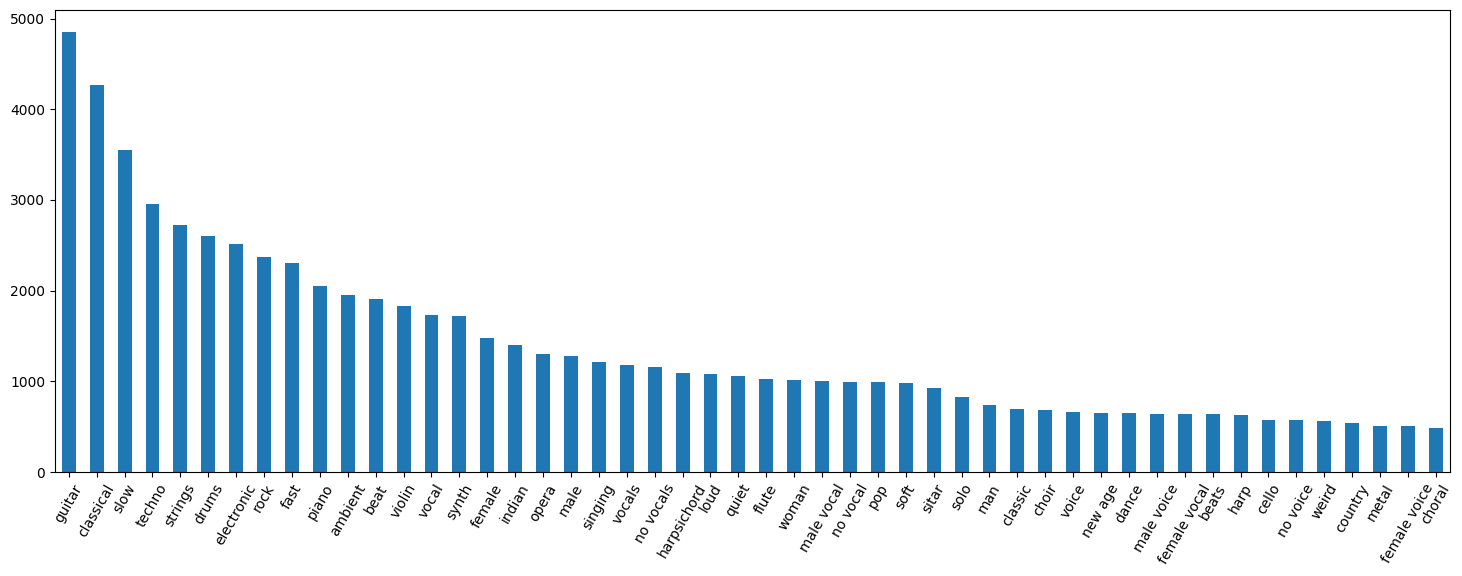

In [934]:
df[TAGS].sum().plot.bar(figsize=(18,6),rot=60) # check data distribution

In [935]:
len(df)

21111

In [936]:
sample_item = df.loc[54327] # sample id
waveform = np.load(os.path.join("./waveform",sample_item['mp3_path'].replace(".mp3",".npy")))
print("annotation tag: ",list(sample_item[sample_item == 1].index))
ipd.Audio(waveform, rate=16000) # load a NumPy array

annotation tag:  ['classical', 'guitar', 'solo', 'strings', 'classical guitar', 'spanish', 'slow']


In [937]:
from torchaudio_augmentations import PitchShift

taudio = PitchShift(sample_rate=16000, n_samples=waveform.size, pitch_shift_min=-3, pitch_shift_max=-3)(torch.from_numpy(waveform).unsqueeze(0)).numpy()

print("Original")
ipd.Audio(taudio, rate=16000)

Original


# Baseline: Training an 1D CNN model from Scratch

This baseline code is provided so that you can easily start the homework and also compare with your own algorithm.
The baseline model extracts mel-spectrogram and has a simple set of 1D CNN model that includes 1D convolutional layers, batch normalization, max-pooling and fully-connected layer.

## Data Preprocessing

In [938]:
train = []
valid = []
test = []
id_to_path = {}
for idx in range(len(df)):
  item = df.iloc[idx]
  id = item.name
  path = item['mp3_path']
  folder = path.split("/")[0]
  id_to_path[id] = path
  if folder in "012ab":
    train.append(id)# split = "train"
  elif folder == "c":
    valid.append(id)# split = "valid"
  elif folder in "d":
    test.append(id)# split = "test"

In [939]:
total = len(train) + len(valid) + len(test)
total, len(train) / total, len(valid)/ total, len(test)/ total

(9074, 0.6839321137315406, 0.16850341635441923, 0.14756446991404013)

In [940]:
df = df[TAGS]

In [941]:
df_train = df.loc[train]
df_valid = df.loc[valid]
df_test = df.loc[test]

<Axes: >

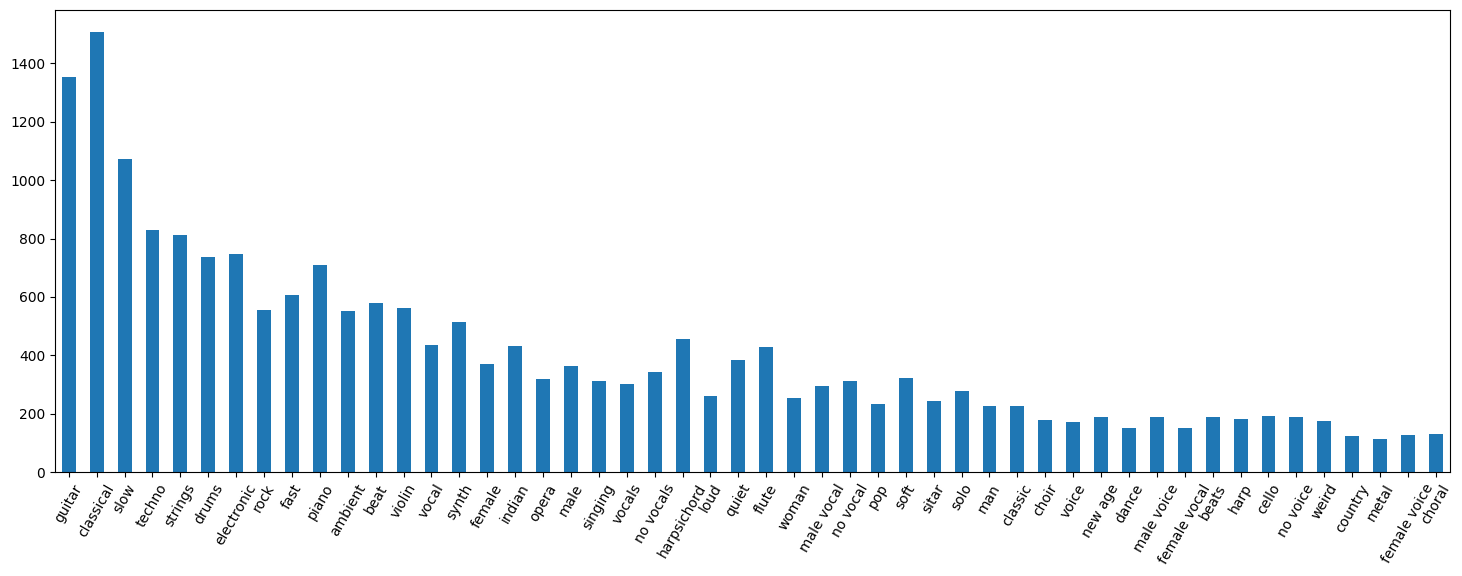

In [942]:
df_train[TAGS].sum().plot.bar(figsize=(18,6),rot=60) # check data distribution

<Axes: >

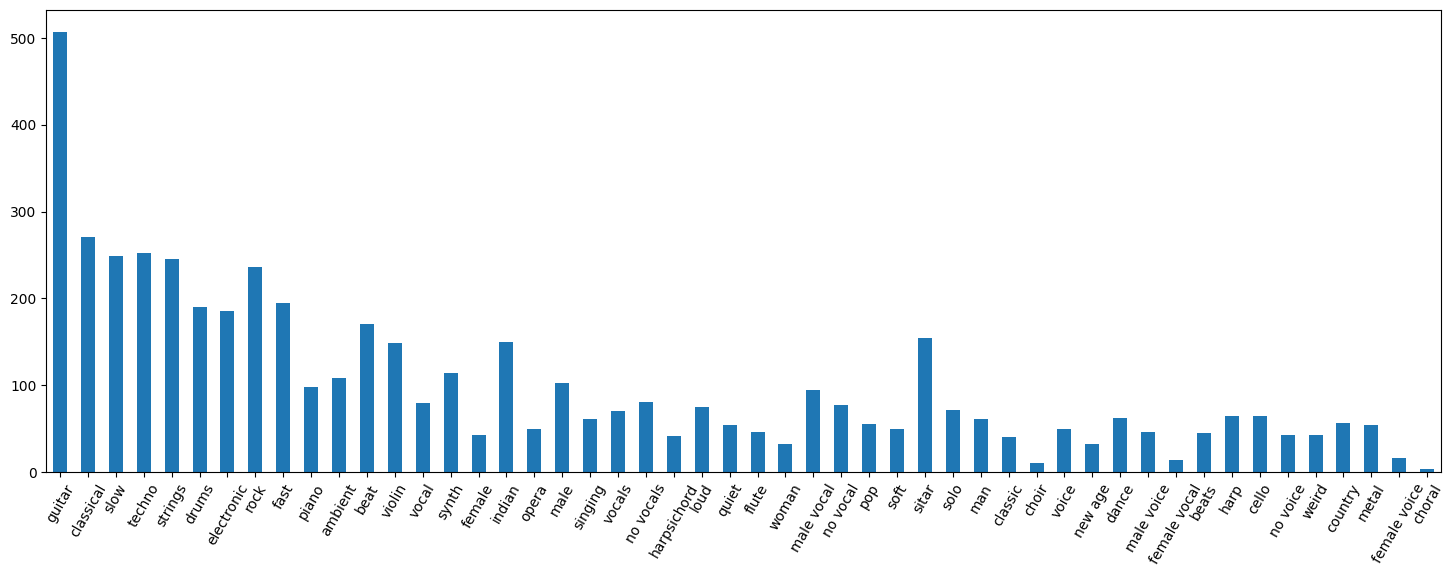

In [943]:
df_valid[TAGS].sum().plot.bar(figsize=(18,6),rot=60) # check data distribution

<Axes: >

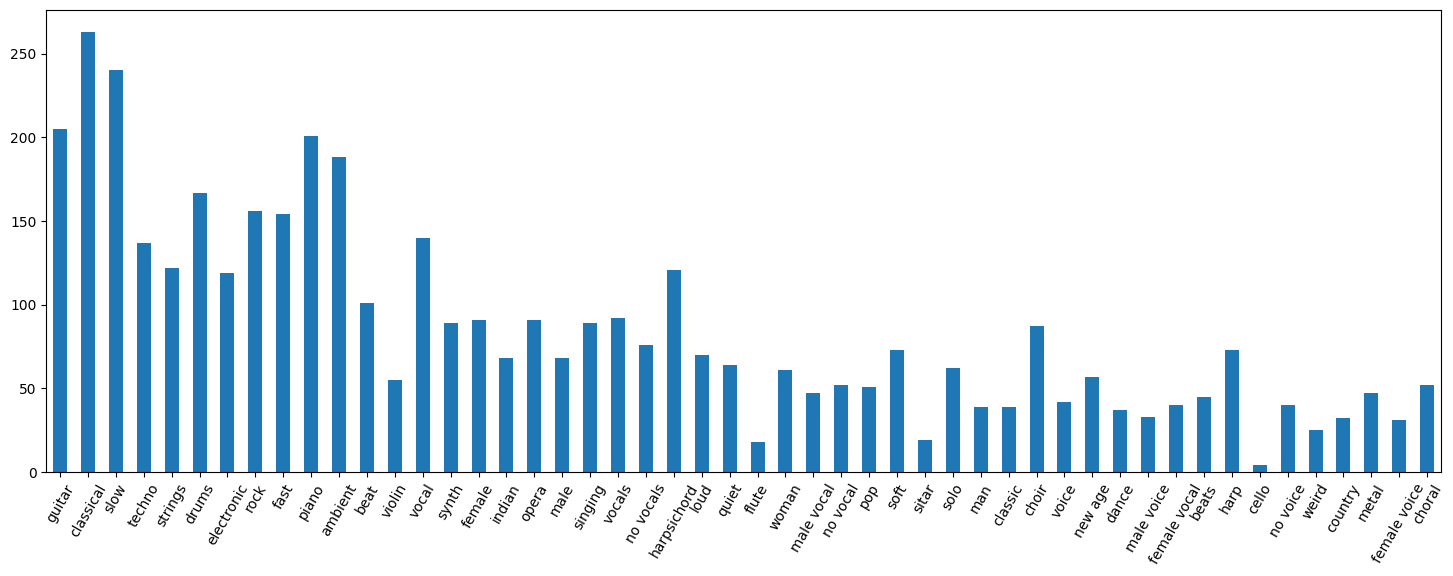

In [944]:
df_test[TAGS].sum().plot.bar(figsize=(18,6),rot=60) # check data distribution

In [945]:
# Data processing setup.
SR = 16000
BATCH_SIZE = 16

## Dataset & DataLoader

In [14]:
from torch.utils.data import Dataset, DataLoader
import numpy as np

class AudioDataset(Dataset):
  def __init__(self, paths, input_length, binary, id_to_path, split):
    self.paths = paths
    self.input_length = input_length
    self.binary = binary
    self.id_to_path = id_to_path
    self.split = split

  def __getitem__(self, index):
    item = self.binary.iloc[index]
    waveform = self.item_to_waveform(item)
    return waveform.astype(np.float32), item.values.astype(np.float32)

  def item_to_waveform(self, item):
    id = item.name
    path = os.path.join(self.paths, self.id_to_path[id].replace(".mp3", ".npy")) # pre-extract waveform, for fast loader
    waveform = np.load(path)
    if self.split in ['TRAIN','VALID']:
      random_idx = np.random.randint(low=0, high=int(waveform.shape[0] - self.input_length))
      waveform = waveform[random_idx:random_idx+self.input_length] # extract input
      audio = np.expand_dims(waveform, axis = 0)# 1 x samples
    elif self.split == 'TEST':
      chunk_number = waveform.shape[0] // self.input_length
      chunk = np.zeros((chunk_number, self.input_length))
      for idx in range(chunk.shape[0]):
        chunk[idx] = waveform[idx:idx+input_length]
      audio = chunk
    return audio

  def __len__(self):
    return len(self.binary)

### Computing statistics of the training set
The code below compute mean, standard deviation and the minimum temporal dimension size, and use them for preprocessing inputs.

In [ ]:
BATCH_SIZE = 16
num_workers = 2
sample_rate = 16000
duration = 3
input_length =  sample_rate * duration
data_path = "./waveform"
tr_data = AudioDataset(data_path, input_length, df_train, id_to_path, 'TRAIN')
va_data = AudioDataset(data_path, input_length, df_valid, id_to_path, 'VALID')
te_data = AudioDataset(data_path, input_length, df_test, id_to_path, 'TEST')
loader_train = DataLoader(tr_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, drop_last=True)
loader_valid = DataLoader(va_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, drop_last=False)
loader_test = DataLoader(te_data, batch_size=1, shuffle=False, num_workers=num_workers, drop_last=False)

## Training the 1D CNN model
The table below shows the architecture of the baseline model

| Layer          | Output Size | Details                 |
|----------------|-------------|-------------------------|
| input          | B x 1 x 16000 * sec,    | batch x channel x samples |
| mel_spec       | B x 96 x 188    | batch x freq x time|
| conv + maxpool | B x 32 x 64    | kernel_size=3, stride=1 |
| conv + maxpool | B x 32 x 22    | kernel_size=3, stride=1 |
| conv + maxpool | B x 32 x 8     | kernel_size=3 stride=1 |
| global_avgpool | B x 32 x 1     | -                       |
| classifier     | B x 50         | -                       |



The folloing code implements the baseline model in PyTorch

In [16]:
import torch.nn as nn

class Baseline(nn.Module):
    def __init__(self,
                sample_rate=16000,
                n_fft=512,
                f_min=0.0,
                f_max=8000.0,
                n_mels=96,
                n_class=50):
        super(Baseline, self).__init__()

        # Spectrogram
        self.spec = torchaudio.transforms.MelSpectrogram(sample_rate=sample_rate,
                                                         n_fft=n_fft,
                                                         f_min=f_min,
                                                         f_max=f_max,
                                                         n_mels=n_mels)
        self.to_db = torchaudio.transforms.AmplitudeToDB()
        self.spec_bn = nn.BatchNorm2d(1)

        self.conv0 = nn.Sequential(
            nn.Conv1d(n_mels, out_channels=32, kernel_size=3, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=3)
            )

        self.conv1 = nn.Sequential(
            nn.Conv1d(32, out_channels=32, kernel_size=3, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=3)
            )

        self.conv2 = nn.Sequential(
            nn.Conv1d(32, out_channels=32, kernel_size=3, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=3)
            )
        # Aggregate features over temporal dimension.
        self.final_pool = nn.AdaptiveAvgPool1d(1)
        # Predict tag using the aggregated features.
        self.linear = nn.Linear(32, n_class)

    def forward(self, x):
        x = self.spec(x)
        x = self.to_db(x)
        x = self.spec_bn(x)
        x = x.squeeze(1) # for 1D conv
        x = self.conv0(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.final_pool(x)
        x = self.linear(x.squeeze(-1))
        x = nn.Sigmoid()(x) # for binary cross entropy loss
        return x

In [58]:
class Runner(object):
  def __init__(self, model, lr, momentum, weight_decay, sr, tags, optimizer="Adam"):
    if optimizer == "Adam":
      self.optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
      self.optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, nesterov=True, weight_decay=weight_decay)
    self.scheduler = CosineAnnealingLR(self.optimizer, T_0=50, T_mult=2, eta_min=0)
    # self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    self.learning_rate = lr
    self.stopping_rate = sr
    self.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    self.model = model.to(self.device)
    self.criterion = torch.nn.BCELoss().to(self.device)
    self.tags = tags

  # Running model for train, test and validation. mode: 'train' for training, 'eval' for validation and test
  def run(self, dataloader, epoch, mode='TRAIN'):
    self.model.train() if mode is 'TRAIN' else self.model.eval()

    epoch_loss = 0
    # pbar = tqdm(dataloader, desc=f'{mode} Epoch {epoch:02}')  # progress bar
    for x, y in tqdm(dataloader, desc=f'{mode} Epoch {epoch:02}'):
      # Move mini-batch to the desired device.
      x = x.to(self.device)
      y = y.to(self.device)
      # Feed forward the model.
      prediction = self.model(x)
      # Compute the loss.
      loss = self.criterion(prediction, y)
      if mode is 'TRAIN':
        # Perform backward propagation to compute gradients.
        loss.backward()
        # Update the parameters.
        self.optimizer.step()
        # Reset the computed gradients.
        self.optimizer.zero_grad()

      batch_size = len(x)
      epoch_loss += batch_size * loss.item()
    epoch_loss = epoch_loss / len(dataloader.dataset)
    return epoch_loss

  def test(self, dataloader):
    self.model.eval()
    epoch_loss = 0
    predictions = []
    labels = []
    # pbar = tqdm(dataloader, desc=f'TEST')  # progress bar
    for x, y in tqdm(dataloader, desc=f'TEST'):
      x = x.to(self.device)
      y = y.to(self.device)
      x = x.transpose(1,0) # pre-batch in audio loader (chunk, 1, waveform)
      prediction = self.model(x)
      prediction = prediction.mean(dim=0, keepdim=True) # average chunk audio
      loss = self.criterion(prediction, y)
      batch_size = len(x)
      epoch_loss += batch_size * loss.item()
      predictions.extend(prediction.detach().cpu().numpy())
      labels.extend(y.detach().cpu().numpy())
    epoch_loss = epoch_loss / len(loader_test.dataset)
    roc_aucs, pr_aucs, tag_wise_rocaucs = self.get_auc(predictions, labels)
    return roc_aucs, pr_aucs, epoch_loss, tag_wise_rocaucs

  # Early stopping function for given validation loss
  def early_stop(self, loss, epoch):
    self.scheduler.step(loss, epoch)
    self.learning_rate = self.optimizer.param_groups[0]['lr']
    stop = self.learning_rate < self.stopping_rate
    return stop

  def get_auc(self, predictions, labels):
    roc_aucs = metrics.roc_auc_score(labels, predictions, average='macro')
    pr_aucs = metrics.average_precision_score(labels, predictions, average='macro')
    tag_wise_predictions = np.stack(predictions).T
    tag_wise_labels = np.stack(labels).T
    tag_wise_rocaucs = {}
    for tag, logit, label in zip(self.tags, tag_wise_predictions, tag_wise_labels):
      tag_wise_rocaucs[tag] = metrics.roc_auc_score(label, logit)
    return roc_aucs, pr_aucs, tag_wise_rocaucs

In [42]:
# Training setup.
LR = 1e-3  # learning rate
SR = 1e-5  # stopping rate
MOMENTUM = 0.9
NUM_EPOCHS = 10 # increase the epoch for your experiment
WEIGHT_DECAY = 0.0  # L2 regularization weight

In [43]:
!jupyter nbextension enable varInspector/main

Enabling notebook extension varInspector/main...
      - Validating: OK


In [20]:
# Iterate over epochs.
model = Baseline()
runner = Runner(model=model, lr = LR, momentum = MOMENTUM, weight_decay = WEIGHT_DECAY, sr = SR, tags=TAGS)
for epoch in range(NUM_EPOCHS):
  train_loss = runner.run(loader_train, epoch, 'TRAIN')
  valid_loss = runner.run(loader_valid, epoch, 'VALID')
  print("[Epoch %d/%d] [Train Loss: %.4f] [Valid Loss: %.4f]" %
        (epoch + 1, NUM_EPOCHS, train_loss, valid_loss))
  if runner.early_stop(valid_loss, epoch + 1):
    break

TRAIN Epoch 00:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 00:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 1/10] [Train Loss: 0.5954] [Valid Loss: 0.4950]


TRAIN Epoch 01:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 01:   0%|          | 0/96 [00:00<?, ?it/s]

...

VALID Epoch 08:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 9/10] [Train Loss: 0.2241] [Valid Loss: 0.2238]


TRAIN Epoch 09:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 09:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 10/10] [Train Loss: 0.2216] [Valid Loss: 0.2215]


In [21]:
roc_aucs, pr_aucs, epoch_loss, tag_wise_rocaucs = runner.test(loader_test)
print(f'test_loss={epoch_loss},  roc_auc={roc_aucs}, pr_auc={pr_aucs}')

TEST:   0%|          | 0/1339 [00:00<?, ?it/s]

test_loss=0.4379406364285474,  roc_auc=0.6301293438463387, pr_auc=0.14297141545499198


<Axes: >

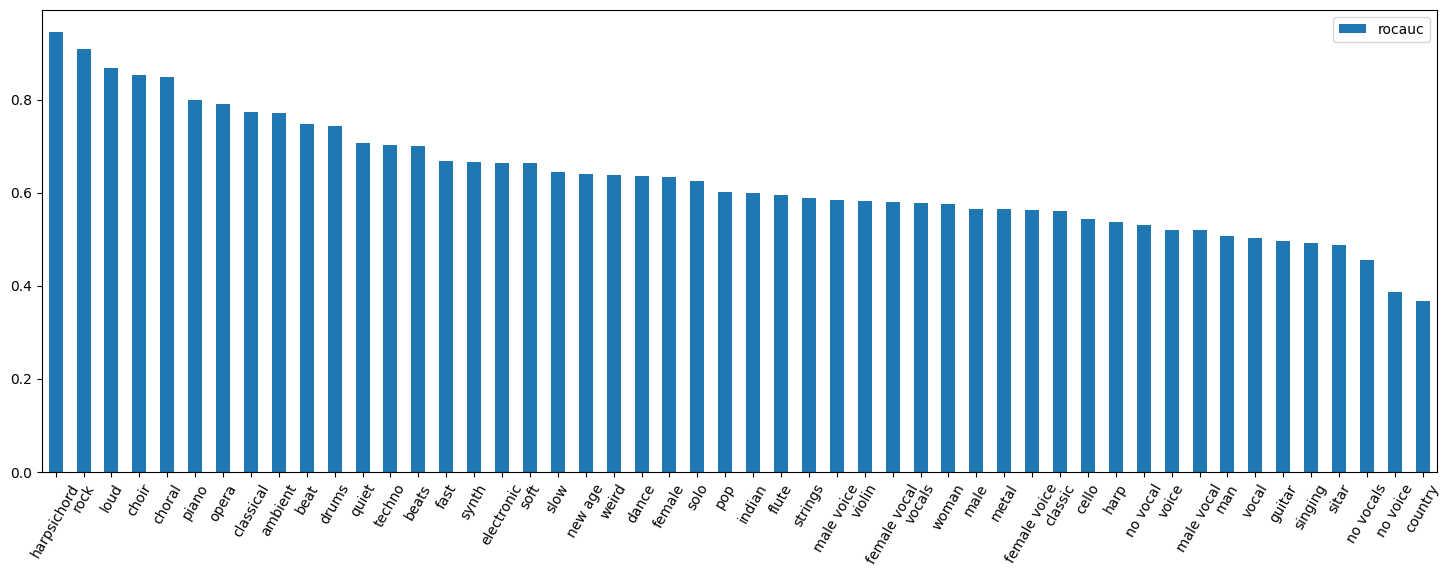

In [22]:
result_auc = pd.DataFrame([tag_wise_rocaucs[tag] for tag in TAGS], columns=['rocauc'], index=TAGS)
result_auc.sort_values(by='rocauc', ascending=False).plot.bar(figsize=(18,6),rot=60) # which tag is easy and hard task

In [946]:
def auto_tagging(waveform, model, input_length, tags, topk):
  device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
  model = model.to(device)
  chunk_number = waveform.shape[0] // input_length
  chunk = np.zeros((chunk_number, input_length))
  for idx in range(chunk.shape[0]):
    chunk[idx] = waveform[idx:idx+input_length]
  audio_tensor = torch.from_numpy(chunk.astype(np.float32))
  predictions = model(audio_tensor.unsqueeze(1).to(device))
  logit = predictions.mean(dim=0, keepdim=False).detach().cpu().numpy()
  annotation = [tags[i] for i in logit.argsort()[::-1][:topk]]
  return annotation

In [24]:
# sample infernece id = 234
id = 234
audio_sample = df_test.loc[id]
waveform = np.load(os.path.join("./waveform",id_to_path[id].replace(".mp3",".npy")))
print("annotation tag: ",list(audio_sample[audio_sample != 0].index))
ipd.Audio(waveform, rate=16000) # load a NumPy array

annotation tag:  ['guitar', 'techno', 'rock', 'fast', 'synth']


In [25]:
annotation = auto_tagging(waveform, runner.model, input_length, TAGS, 5)
print("model predict tags: ",annotation)

model predict tags:  ['classical', 'guitar', 'drums', 'slow', 'beat']


### [Question 1] Implement a 2D CNN architecture.
Implement a 2D CNN with the folloing configuration.

| Layer          | Output Size | Details                 |
|----------------|-------------|-------------------------|
| input          | B x 1 x sample_rate * duration,    | batch x channel (mono) x samples |
| mel_spec       | B x 1 x 96 x 188    | batch x channel (mono) x freq x time|
| conv + maxpool | B x 64 x 24 x 47    | output_channels=64, kernel_size=3, pooling=(4,4) |
| conv + maxpool | B x 128 x 8 x 15    | output_channels=128, kernel_size=3, pooling=(3,3) |
| conv + maxpool | B x 128 x  2 x 5     | output_channels=128, kernel_size=3 pooling=(3,3) |
| conv + maxpool | B x 64 x 1 x 1      | output_channels=64, kernel_size=3 pooling=(2,5)                    |
| classifier     | B x 50         | -                       |


Note: you should give appropriate paddings!

The folowing is the startup code. Fill in the "to-do" area.

In [366]:
import torch.nn as nn

class Conv_2d(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size=3, stride=1, padding=1, pooling=2):
        super(Conv_2d, self).__init__()
        # To do
        #========================================
        self.conv = nn.Conv2d(input_channels, output_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU()
        self.mp = nn.MaxPool2d(kernel_size=pooling, stride=pooling)
        #========================================
    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.mp(out)
        return out

class CNN2D(nn.Module):
    def __init__(self,
                sample_rate=16000,
                n_fft=512,
                f_min=0.0,
                f_max=8000.0,
                n_mels=96,
                n_class=50):
        super(CNN2D, self).__init__()

        # Spectrogram
        self.spec = torchaudio.transforms.MelSpectrogram(sample_rate=sample_rate,
                                                         n_fft=n_fft,
                                                         f_min=f_min,
                                                         f_max=f_max,
                                                         n_mels=n_mels)
        self.to_db = torchaudio.transforms.AmplitudeToDB()
        self.spec_bn = nn.BatchNorm2d(1)
        # To do
        #========================================
        self.layer1 = Conv_2d(1, 64, kernel_size=3, stride=1, padding=1, pooling=4)
        self.layer2 = Conv_2d(64, 128, kernel_size=3, stride=1, padding=1, pooling=3)
        self.layer3 = Conv_2d(128, 128, kernel_size=3, stride=1, padding=1, pooling=3)
        self.layer4 = Conv_2d(128, 64, kernel_size=3, stride=1, padding=1, pooling=(2,5))
        #========================================
        self.linear = nn.Linear(64, n_class)
    def forward(self, x):
        x = self.spec(x)
        x = self.to_db(x)
        x = self.spec_bn(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.view(x.size(0), -1)
        x = self.linear(x)
        x = nn.Sigmoid()(x) # for binary cross entropy loss
        return x

### [Question 2] Improve the performeance.
Now it is your turn. You can improve the model performance with your own idea.

In [947]:
from torch.utils.data import Dataset, DataLoader
import numpy as np

from torchaudio_augmentations import RandomApply, PitchShift, RandomResizedCrop, Noise, Gain, HighLowPass, Delay, Reverb, Compose, PolarityInversion

class AudioDataset(Dataset):
  def __init__(self, paths, input_length, binary, id_to_path, split, sample_rate, aug=True, mix_ratio=0.0):
    self.paths = paths
    self.input_length = input_length
    self.binary = binary

    self.no_voice_binary = self.binary[self.binary[['no vocal', 'no voice', 'no vocals']].sum(axis=1) != 0]
    self.id_to_path = id_to_path
    self.sample_rate = sample_rate
    self.split = split
    self.mix_ratio = mix_ratio

    if aug:
      self._get_augmentations()
    else:
      self.augmentations = None

  def _get_augmentations(self):
    transforms = [
      RandomApply([Noise(min_snr=0.1, max_snr=0.2)], p=0.5),
      # RandomApply([PolarityInversion()], p=0.8),
      # RandomApply([HighLowPass(sample_rate=self.sample_rate)], p=0.5),
      RandomApply([PitchShift(n_samples=self.input_length, sample_rate=self.sample_rate, pitch_shift_min=-3, pitch_shift_max=3)], p=0.5),
      # RandomApply([Delay(sample_rate=self.sample_rate)], p=0.5),
      RandomApply([Reverb(sample_rate=self.sample_rate)], p=0.4),
    ]
    self.augmentations = Compose(transforms)    

  def _get_weak_mixture(self):
    idx1 = np.random.randint(low=0, high=len(self.no_voice_binary)-1)
    idx2 = np.random.randint(low=0, high=len(self.no_voice_binary)-1)

    item1 = self.no_voice_binary.iloc[idx1]
    item2 = self.no_voice_binary.iloc[idx2]
    audio1 = self.item_to_waveform(item1)
    audio2 = self.item_to_waveform(item2)
    alpha = np.random.uniform(0.2, 0.8)

    total_length = min(audio1.shape[1], audio2.shape[1])
    audio1_len = int(total_length * alpha)
    audio2_len = total_length - audio1_len

    audio_idx1 = np.random.randint(low=0, high=int(total_length - audio1_len - 1))
    audio_idx2 = np.random.randint(low=0, high=int(total_length - audio2_len - 1))
    audio1 = audio1[:, audio_idx1:audio_idx1+audio1_len]
    audio2 = audio2[:, audio_idx2:audio_idx2+audio2_len]

    waveform = np.concatenate([audio1, audio2], axis=1)

    label = item1.values + item2.values
    label[label > 1] = 1

    return waveform.astype(np.float32), label.astype(np.float32)

  def __getitem__(self, index):
    if index >= len(self.binary):
      return self._get_weak_mixture()

    item = self.binary.iloc[index]
    waveform = self.item_to_waveform(item)
    return waveform.astype(np.float32), item.values.astype(np.float32)

  def item_to_waveform(self, item):
    id = item.name
    path = os.path.join(self.paths, self.id_to_path[id].replace(".mp3", ".npy")) # pre-extract waveform, for fast loader
    waveform = np.load(path)
    if self.split in ['TRAIN','VALID']:
      random_idx = np.random.randint(low=0, high=int(waveform.shape[0] - self.input_length))
      waveform = waveform[random_idx:random_idx+self.input_length] # extract input

      if self.split == 'TRAIN' and self.augmentations is not None:
        waveform = torch.from_numpy(waveform.astype(np.float32)).unsqueeze(0)
        waveform = self.augmentations(waveform).squeeze(0).numpy() # augmentations
      
      audio = np.expand_dims(waveform, axis = 0)# 1 x samples
    elif self.split == 'TEST':
      chunk_number = waveform.shape[0] // self.input_length
      chunk = np.zeros((chunk_number, self.input_length))
      for idx in range(chunk.shape[0]):
        chunk[idx] = waveform[idx:idx+input_length]
      audio = chunk
    return audio

  def __len__(self):
    return len(self.binary) + np.round(self.mix_ratio * len(self.binary)).astype(int)

In [948]:
BATCH_SIZE = 16
num_workers = 4
sample_rate = 16000
duration = 3
input_length =  sample_rate * duration
data_path = "./waveform"
tr_data = AudioDataset(data_path, input_length, df_train, id_to_path, 'TRAIN', sample_rate)
va_data = AudioDataset(data_path, input_length, df_valid, id_to_path, 'VALID', sample_rate)
te_data = AudioDataset(data_path, input_length, df_test, id_to_path, 'TEST', sample_rate)

use_sampler = False
if use_sampler:
    from torch.utils.data import WeightedRandomSampler

    # Step 1: Compute tag-level inverse frequency (rare tags get higher weight)
    tag_freq = df[TAGS].sum()
    tag_weights = 1.0 / (tag_freq + 1e-6)  # avoid division by zero

    # Step 2: Compute sample-level weights by summing over tag weights per sample
    sample_weights = df_train[TAGS] @ tag_weights  # shape: (num_samples,)

    sample_weights = sample_weights / sample_weights.sum()
    # Step 3: Create the sampler
    sampler = WeightedRandomSampler(
        weights=sample_weights.values,  # or use torch.tensor(sample_weights.values)
        num_samples=len(df_train),
        replacement=False
    )

    loader_train = DataLoader(tr_data, batch_size=BATCH_SIZE, sampler=sampler, num_workers=num_workers, drop_last=True)
else: 
    loader_train = DataLoader(tr_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, drop_last=True)
loader_valid = DataLoader(va_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, drop_last=False)
loader_test = DataLoader(te_data, batch_size=1, shuffle=False, num_workers=num_workers, drop_last=False)

In [949]:
class Res_2d(nn.Module):
    def __init__(self, input_channels, output_channels, shape=3, stride=2):
        super(Res_2d, self).__init__()
        # convolution
        self.conv_1 = nn.Conv2d(input_channels, output_channels, shape, stride=stride, padding=shape//2)
        self.bn_1 = nn.BatchNorm2d(output_channels)
        self.conv_2 = nn.Conv2d(output_channels, output_channels, shape, padding=shape//2)
        self.bn_2 = nn.BatchNorm2d(output_channels)

        # residual
        self.diff = False
        if (stride != 1) or (input_channels != output_channels):
            self.conv_3 = nn.Conv2d(input_channels, output_channels, shape, stride=stride, padding=shape//2)
            self.bn_3 = nn.BatchNorm2d(output_channels)
            self.diff = True
        self.relu = nn.ReLU()

    def forward(self, x):
        # convolution
        out = self.bn_2(self.conv_2(self.relu(self.bn_1(self.conv_1(x)))))

        # residual
        if self.diff:
            x = self.bn_3(self.conv_3(x))
        out = x + out
        out = self.relu(out)
        return out


In [950]:
class ShortChunkCNN_Res(nn.Module):
    '''
    Short-chunk CNN architecture with residual connections.
    '''
    def __init__(self,
                n_channels=64,
                sample_rate=16000,
                n_fft=512,
                f_min=0.0,
                f_max=8000.0,
                n_mels=96,
                n_class=50):
        super(ShortChunkCNN_Res, self).__init__()

        # Spectrogram
        self.spec = torchaudio.transforms.MelSpectrogram(sample_rate=sample_rate,
                                                         n_fft=n_fft,
                                                         f_min=f_min,
                                                         f_max=f_max,
                                                         n_mels=n_mels)
        self.to_db = torchaudio.transforms.AmplitudeToDB()
        self.spec_bn = nn.BatchNorm2d(1)

        # CNN
        self.layer1 = Res_2d(1, n_channels, stride=2)
        self.layer2 = Res_2d(n_channels, n_channels, stride=2)
        self.layer3 = Res_2d(n_channels, n_channels*2, stride=2)
        self.layer4 = Res_2d(n_channels*2, n_channels*2, stride=2)
        # self.layer4 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.layer5 = Res_2d(n_channels*2, n_channels*2, stride=2)
        self.layer6 = Res_2d(n_channels*2, n_channels*2, stride=2)
        self.layer7 = Res_2d(n_channels*2, n_channels*4, stride=2)

        # Dense
        self.dense1 = nn.Linear(n_channels*4, n_channels*4)
        self.bn = nn.BatchNorm1d(n_channels*4)
        self.dense2 = nn.Linear(n_channels*4, n_class)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()
        
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Spectrogram
        x = self.spec(x)
        x = self.to_db(x)
        x = self.spec_bn(x)

        # CNN
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.layer6(x)
        x = self.layer7(x)
        x = x.squeeze(2)

        # Global Max Pooling
        if x.size(-1) != 1:
            x = nn.MaxPool1d(x.size(-1))(x)
        x = x.squeeze(2)

        # Dense
        x = self.dense1(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.dense2(x)
        x = nn.Sigmoid()(x)

        return x


In [ ]:
class Runner(object):
  def __init__(self, model, lr, momentum, weight_decay, sr, tags, optimizer="Adam", loss="BCE"):
    if optimizer == "Adam":
      self.optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
      self.optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, nesterov=True, weight_decay=weight_decay)
    # self.scheduler = CosineAnnealingLR(self.optimizer, T_max=30, eta_min=0)
    self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=0.2, patience=5, verbose=True)
    self.learning_rate = lr
    self.stopping_rate = sr
    self.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    self.model = model.to(self.device)

    if loss == "BCE":
      self.criterion = torch.nn.BCELoss().to(self.device)
    elif loss == "BCEWithLogits":
      label_counts = df[TAGS].sum()
      pos_weight = (len(df[TAGS]) - label_counts) / (label_counts + 1e-6)
      pos_weight = torch.tensor(pos_weight.values, dtype=torch.float32)
      self.criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(self.device)
    else:
      self.criterion = torch.nn.BCELoss().to(self.device)
    self.tags = tags

  # Running model for train, test and validation. mode: 'train' for training, 'eval' for validation and test
  def run(self, dataloader, epoch, mode='TRAIN'):
    self.model.train() if mode is 'TRAIN' else self.model.eval()

    epoch_loss = 0
    # pbar = tqdm(dataloader, desc=f'{mode} Epoch {epoch:02}')  # progress bar
    for x, y in tqdm(dataloader, desc=f'{mode} Epoch {epoch:02}'):
      # Move mini-batch to the desired device.
      x = x.to(self.device)
      y = y.to(self.device)
      # Feed forward the model.
      prediction = self.model(x)
      # Compute the loss.
      loss = self.criterion(prediction, y)
      if mode is 'TRAIN':
        # Perform backward propagation to compute gradients.
        loss.backward()
        # Update the parameters.
        self.optimizer.step()
        # Reset the computed gradients.
        self.optimizer.zero_grad()

      batch_size = len(x)
      epoch_loss += batch_size * loss.item()
    epoch_loss = epoch_loss / len(dataloader.dataset)
    return epoch_loss

  def test(self, dataloader):
    self.model.eval()
    epoch_loss = 0
    predictions = []
    labels = []
    # pbar = tqdm(dataloader, desc=f'TEST')  # progress bar
    for x, y in tqdm(dataloader, desc=f'TEST'):
      x = x.to(self.device)
      y = y.to(self.device)
      x = x.transpose(1,0) # pre-batch in audio loader (chunk, 1, waveform)
      prediction = self.model(x)
      prediction = prediction.mean(dim=0, keepdim=True) # average chunk audio
      loss = self.criterion(prediction, y)
      batch_size = len(x)
      epoch_loss += batch_size * loss.item()
      predictions.extend(prediction.detach().cpu().numpy())
      labels.extend(y.detach().cpu().numpy())
    epoch_loss = epoch_loss / len(loader_test.dataset)
    roc_aucs, pr_aucs, tag_wise_rocaucs = self.get_auc(predictions, labels)
    return roc_aucs, pr_aucs, epoch_loss, tag_wise_rocaucs

  # Early stopping function for given validation loss
  def early_stop(self, loss, epoch):
    self.scheduler.step(loss, epoch)
    self.learning_rate = self.optimizer.param_groups[0]['lr']
    stop = self.learning_rate < self.stopping_rate
    return stop

  def get_auc(self, predictions, labels):
    roc_aucs = metrics.roc_auc_score(labels, predictions, average='macro')
    pr_aucs = metrics.average_precision_score(labels, predictions, average='macro')
    tag_wise_predictions = np.stack(predictions).T
    tag_wise_labels = np.stack(labels).T
    tag_wise_rocaucs = {}
    for tag, logit, label in zip(self.tags, tag_wise_predictions, tag_wise_labels):
      tag_wise_rocaucs[tag] = metrics.roc_auc_score(label, logit)
    return roc_aucs, pr_aucs, tag_wise_rocaucs

In [955]:
# Training setup.
LR = 5e-4  # learning rate
SR = 1e-5  # stopping rate
MOMENTUM = 0.9
NUM_EPOCHS = 35 # increase the epoch for your experiment
WEIGHT_DECAY = 1e-2  # L2 regularization weight

In [956]:
torch.manual_seed(0)
model = ShortChunkCNN_Res()
runner = Runner(model=model, lr = LR, momentum = MOMENTUM, weight_decay = WEIGHT_DECAY, sr = SR, tags=TAGS, optimizer="Adam", loss="BCE")

train_losses = []
valid_losses = []

for epoch in range(NUM_EPOCHS):
  train_loss = runner.run(loader_train, epoch, 'TRAIN')
  valid_loss = runner.run(loader_valid, epoch, 'VALID')

  train_losses.append(train_loss)
  valid_losses.append(valid_loss)
  
  print("[Epoch %d/%d] [Train Loss: %.4f] [Valid Loss: %.4f]" %
        (epoch + 1, NUM_EPOCHS, train_loss, valid_loss))
  if runner.early_stop(valid_loss, epoch + 1):
    break

TRAIN Epoch 00:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 00:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 1/35] [Train Loss: 0.2771] [Valid Loss: 0.2007]


TRAIN Epoch 01:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 01:   0%|          | 0/96 [00:00<?, ?it/s]

...

VALID Epoch 33:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 34/35] [Train Loss: 0.1418] [Valid Loss: 0.1541]


TRAIN Epoch 34:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 34:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 35/35] [Train Loss: 0.1428] [Valid Loss: 0.1538]


In [957]:
roc_aucs, pr_aucs, epoch_loss, tag_wise_rocaucs = runner.test(loader_test)
print(f'test_loss={epoch_loss},  roc_auc={roc_aucs}, pr_auc={pr_aucs}')

TEST:   0%|          | 0/1339 [00:00<?, ?it/s]

test_loss=0.3129354310684501,  roc_auc=0.8666358889354536, pr_auc=0.3558295832195187


In [958]:
NUM_EPOCHS_FT = 10
for epoch in range(NUM_EPOCHS_FT):
  train_loss = runner.run(loader_train, epoch, 'TRAIN')
  valid_loss = runner.run(loader_valid, epoch, 'VALID')

  train_losses.append(train_loss)
  valid_losses.append(valid_loss)
  
  print("[Epoch %d/%d] [Train Loss: %.4f] [Valid Loss: %.4f]" %
        (epoch + 1, NUM_EPOCHS, train_loss, valid_loss))
  if runner.early_stop(valid_loss, epoch + 1):
    break

TRAIN Epoch 00:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 00:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 1/35] [Train Loss: 0.1366] [Valid Loss: 0.1465]


TRAIN Epoch 01:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 01:   0%|          | 0/96 [00:00<?, ?it/s]

...

VALID Epoch 08:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 9/35] [Train Loss: 0.1298] [Valid Loss: 0.1484]


TRAIN Epoch 09:   0%|          | 0/387 [00:00<?, ?it/s]

VALID Epoch 09:   0%|          | 0/96 [00:00<?, ?it/s]

[Epoch 10/35] [Train Loss: 0.1297] [Valid Loss: 0.1483]


In [959]:
roc_aucs, pr_aucs, epoch_loss, tag_wise_rocaucs = runner.test(loader_test)
print(f'test_loss={epoch_loss},  roc_auc={roc_aucs}, pr_auc={pr_aucs}')

TEST:   0%|          | 0/1339 [00:00<?, ?it/s]

test_loss=0.3007553144260028,  roc_auc=0.8777904836608991, pr_auc=0.3739929957470948


<Axes: >

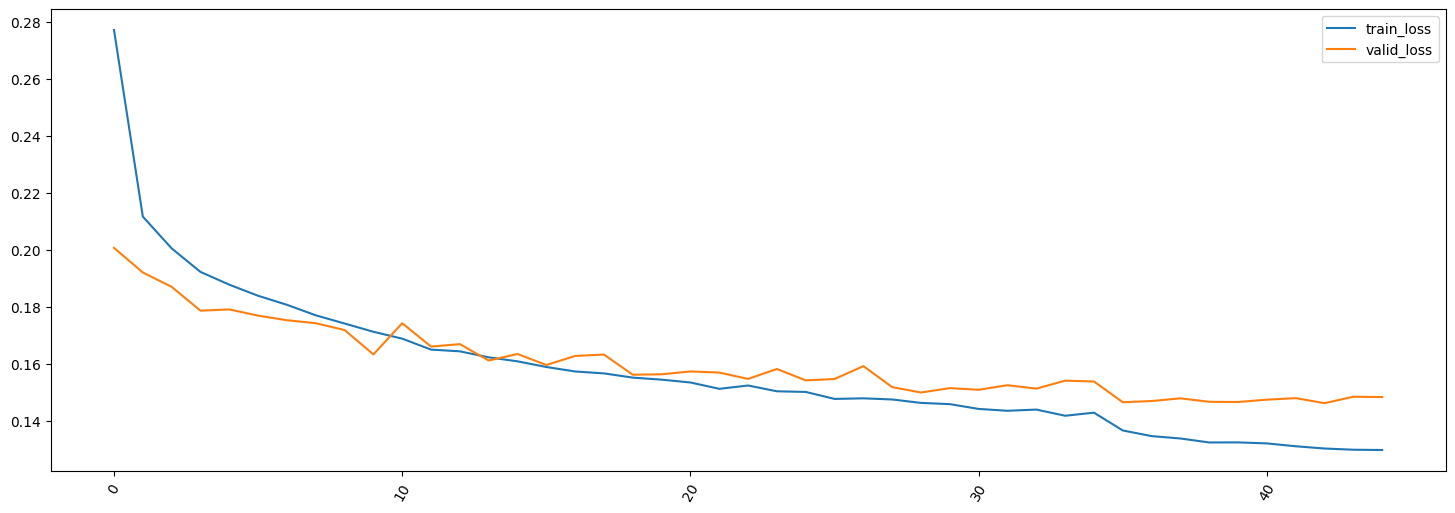

In [960]:
result_loss = pd.DataFrame([train_losses, valid_losses], index=['train_loss', 'valid_loss']).T
result_loss.plot(figsize=(18,6),rot=60) # check loss trend

<Axes: >

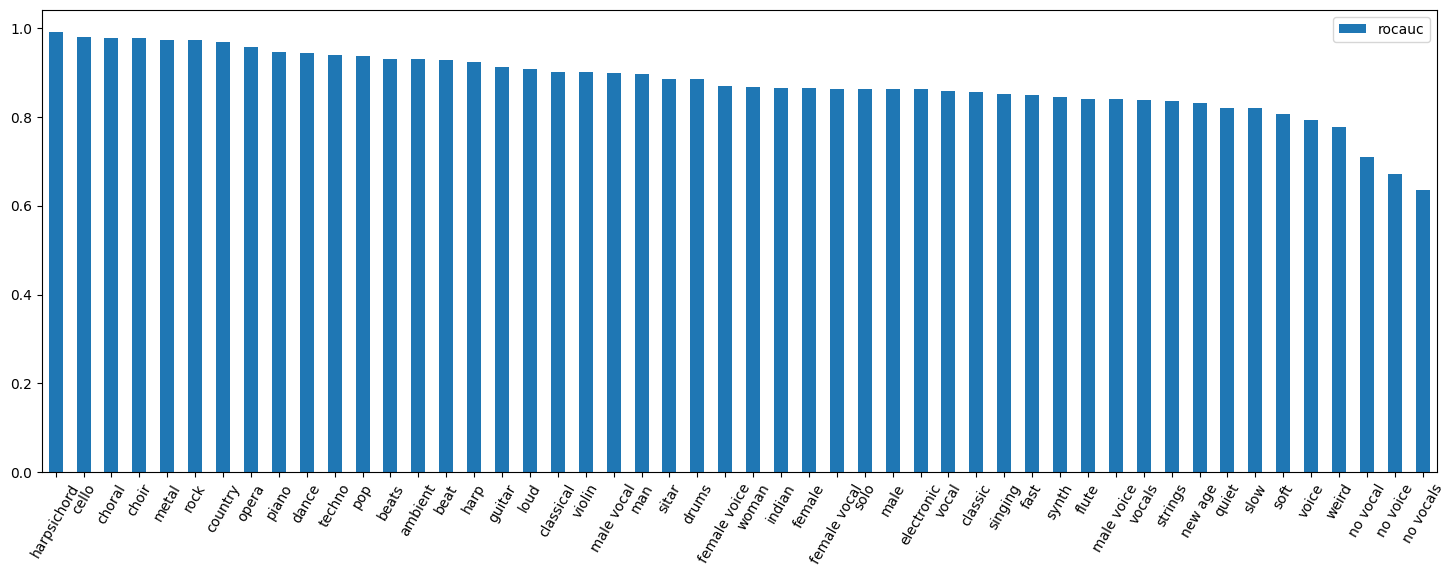

In [961]:
result_auc = pd.DataFrame([tag_wise_rocaucs[tag] for tag in TAGS], columns=['rocauc'], index=TAGS)
result_auc.sort_values(by='rocauc', ascending=False).plot.bar(figsize=(18,6),rot=60) # which tag is easy and hard task

In [962]:
# sample infernece id = 234
id = 234
audio_sample = df_test.loc[id]
waveform = np.load(os.path.join("./waveform",id_to_path[id].replace(".mp3",".npy")))
print("annotation tag: ",list(audio_sample[audio_sample != 0].index))
ipd.Audio(waveform, rate=16000) # load a NumPy array

annotation tag:  ['guitar', 'techno', 'rock', 'fast', 'synth']


In [963]:
annotation = auto_tagging(waveform, runner.model, input_length, TAGS, 5)
print("model predict tags: ",annotation)

model predict tags:  ['techno', 'rock', 'electronic', 'fast', 'drums']


# Credit
This homework was implemented and improved by Jongpil Lee, Soonbeom Choi, Taejun Kim, SeungHeon Doh, and Juhan Nam from the KAIST Music and Audio Computing Lab.
